In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
!unzip /content/dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/TRAIN/R/R_8305.jpg  
  inflating: /content/dataset/TRAIN/R/R_8306.jpg  
  inflating: /content/dataset/TRAIN/R/R_8307.jpg  
  inflating: /content/dataset/TRAIN/R/R_8308.jpg  
  inflating: /content/dataset/TRAIN/R/R_8309.jpg  
  inflating: /content/dataset/TRAIN/R/R_8310.jpg  
  inflating: /content/dataset/TRAIN/R/R_8311.jpg  
  inflating: /content/dataset/TRAIN/R/R_8312.jpg  
  inflating: /content/dataset/TRAIN/R/R_8313.jpg  
  inflating: /content/dataset/TRAIN/R/R_8314.jpg  
  inflating: /content/dataset/TRAIN/R/R_8315.jpg  
  inflating: /content/dataset/TRAIN/R/R_8316.jpg  
  inflating: /content/dataset/TRAIN/R/R_8317.jpg  
  inflating: /content/dataset/TRAIN/R/R_8318.jpg  
  inflating: /content/dataset/TRAIN/R/R_8319.jpg  
  inflating: /content/dataset/TRAIN/R/R_8320.jpg  
  inflating: /content/dataset/TRAIN/R/R_8321.jpg  
  inflating: /content/dataset/TRAIN/R/R_8322.jpg  
  inflating: /content/dataset/T

**Load Images Using Appropriate Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
train_dir = "/content/dataset/TRAIN"
val_dir = "/content/dataset/VALID"
test_dir = "/content/dataset/TEST"

**Verify Dataset Size**

In [ ]:


def count_images(folder):
    total = 0
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        if os.path.isdir(class_path):
            total += len(os.listdir(class_path))
    return total

print("Training Images:", count_images(train_dir))
print("Validation Images:", count_images(val_dir))
print("Test Images:", count_images(test_dir))

Training Images: 15400
Validation Images: 3300
Test Images: 3300


**Verify Dataset Balance (Class Distribution)**

In [ ]:
from collections import Counter


def class_distribution(folder):
    distribution = {}
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        if os.path.isdir(class_path):
            distribution[class_name] = len(os.listdir(class_path))
    return distribution

print("Training Distribution:", class_distribution(train_dir))
print("Validation Distribution:", class_distribution(val_dir))
print("Test Distribution:", class_distribution(test_dir))

Training Distribution: {'O': 7700, 'R': 7700}
Validation Distribution: {'O': 1650, 'R': 1650}
Test Distribution: {'O': 1650, 'R': 1650}


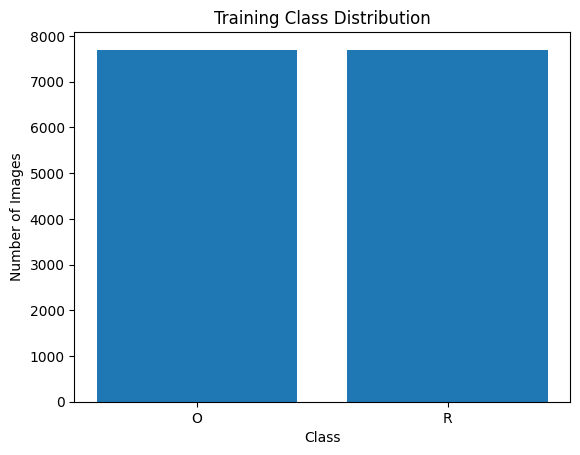

In [ ]:


train_dist = class_distribution(train_dir)

plt.bar(train_dist.keys(), train_dist.values())
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

**Display Sample Images from Each Class**

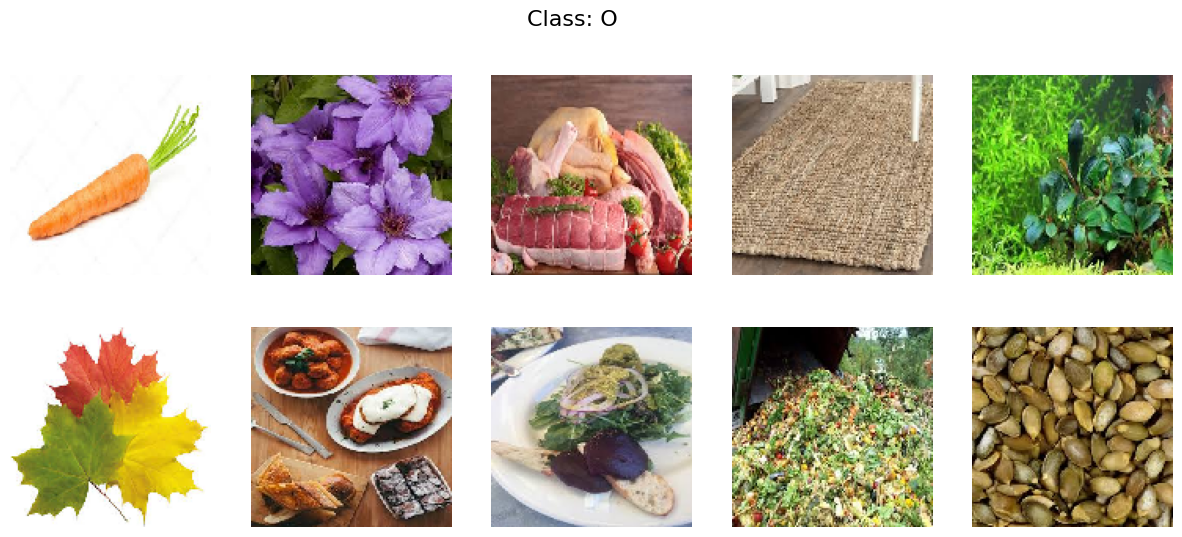

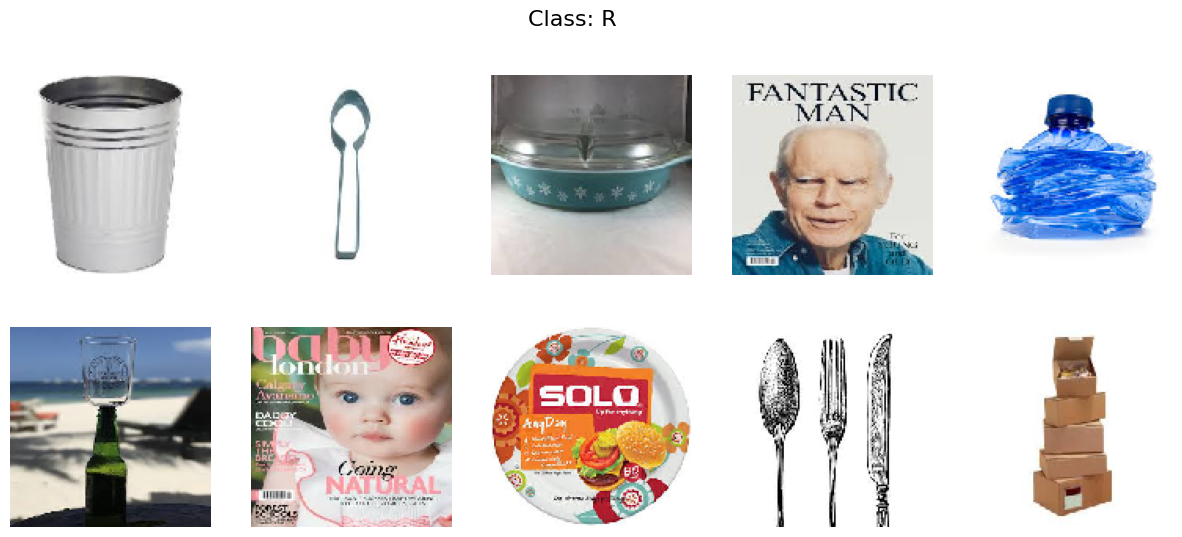

In [ ]:
def show_10_images_each_class(folder):
    classes = os.listdir(folder)

    for class_name in classes:
        class_path = os.path.join(folder, class_name)
        image_files = os.listdir(class_path)

        # Randomly select 10 images
        sample_images = random.sample(image_files, 10)

        plt.figure(figsize=(15,6))
        plt.suptitle(f"Class: {class_name}", fontsize=16)

        for i, image_name in enumerate(sample_images):
            image_path = os.path.join(class_path, image_name)

            img = tf.keras.preprocessing.image.load_img(
                image_path, target_size=(128,128)
            )

            plt.subplot(2,5,i+1)   # 2 rows × 5 columns = 10 images
            plt.imshow(img)
            plt.axis("off")

        plt.show()

# Call function
show_10_images_each_class(train_dir)

**Image Preprocessing**

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255   # Normalize pixel values (0-255 → 0-1)
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),   # Resize images
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(train_generator.class_indices)

Found 15400 images belonging to 2 classes.
Found 3300 images belonging to 2 classes.
Found 3300 images belonging to 2 classes.
{'O': 0, 'R': 1}


**Build CNN Model**

In [ ]:
model = models.Sequential()

# Convolution Block 1
model.add(layers.Conv2D(4, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((2,2)))

# Convolution Block 2
model.add(layers.Conv2D(8, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolution Block 3
model.add(layers.Conv2D(16, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(32, activation='relu'))

# Output Layer (Binary Classification)
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 8)    │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       346,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,753 (1.33 MB)

 Trainable params: 347,753 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

**compile and train the model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 40s 143ms/step - accuracy: 0.7264 - loss: 0.5382 - val_accuracy: 0.8794 - val_loss: 0.3406
Epoch 2/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 31s 127ms/step - accuracy: 0.8210 - loss: 0.4129 - val_accuracy: 0.8794 - val_loss: 0.3009
Epoch 3/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 31s 127ms/step - accuracy: 0.8355 - loss: 0.3835 - val_accuracy: 0.8885 - val_loss: 0.2953
Epoch 4/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 31s 128ms/step - accuracy: 0.8541 - loss: 0.3480 - val_accuracy: 0.8797 - val_loss: 0.3000
Epoch 5/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 30s 123ms/step - accuracy: 0.8561 - loss: 0.3332 - val_accuracy: 0.8894 - val_loss: 0.2943
Epoch 6/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 0.8772 - loss: 0.2993 - val_accuracy: 0.9003 - val_loss: 0.2665
Epoch 7/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 0.8877 - loss: 0.2801 - val_accuracy: 0.8958 - val_loss: 0.2660
Epoch 8/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 34s 140ms/step - accuracy: 0.8999 - loss: 0

**Display Training & Validation Accuracy/Loss**

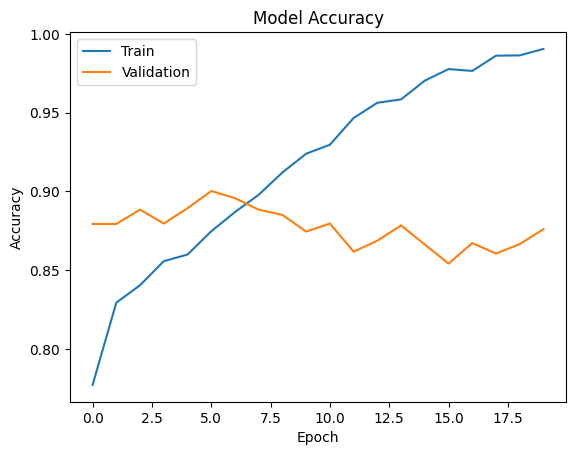

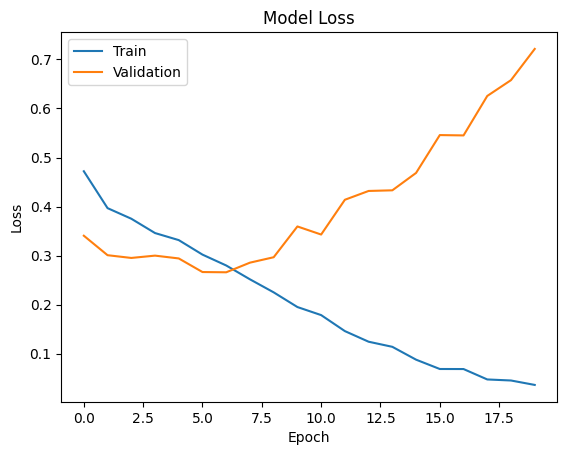

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

**Evaluate on Test Dataset**

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.8179 - loss: 1.0435
Test Accuracy: 0.8257575631141663


**Confusion Matrix**

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step


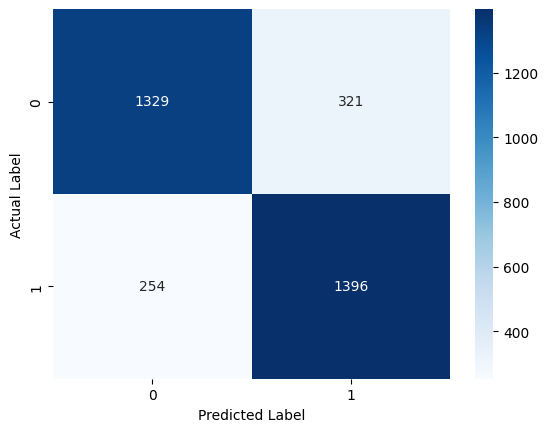

In [ ]:
predictions = model.predict(test_generator)
y_pred = np.round(predictions)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Show Sample Predictions**

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 


/tmp/ipython-input-1394988374.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("Predicted: " + class_labels[int(np.round(prediction[0]))])


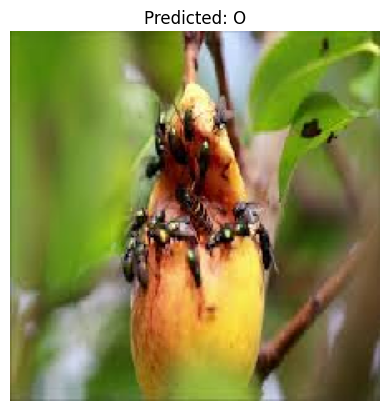

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


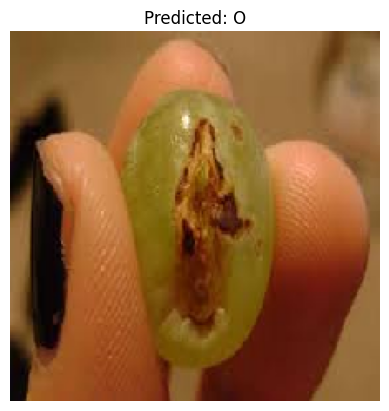

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


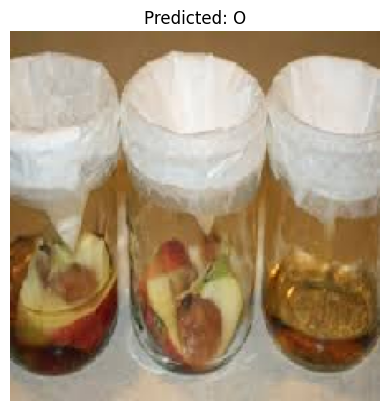

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


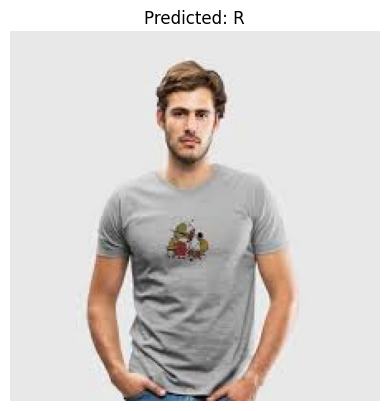

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


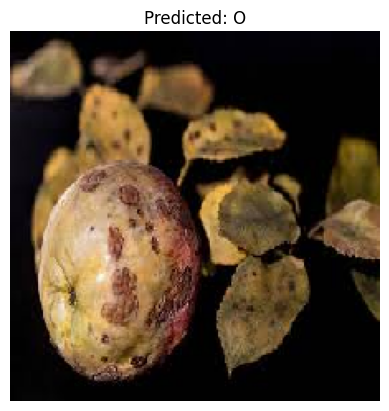

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


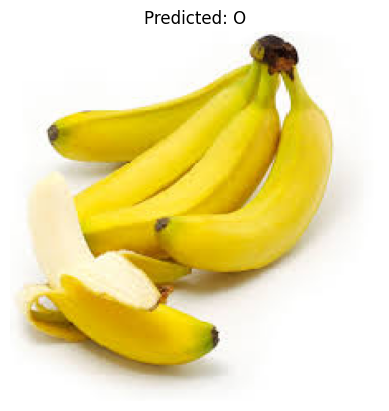

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


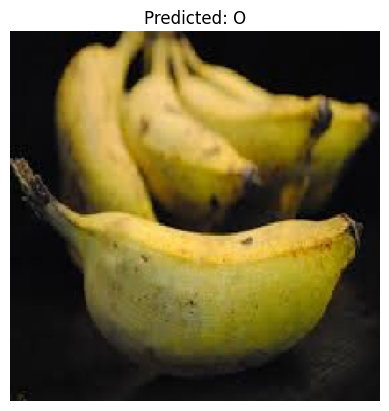

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


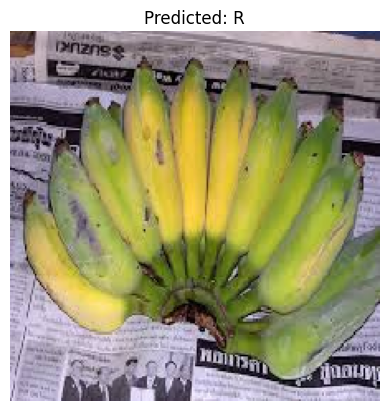

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


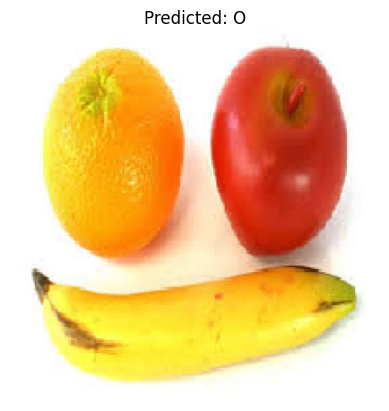

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


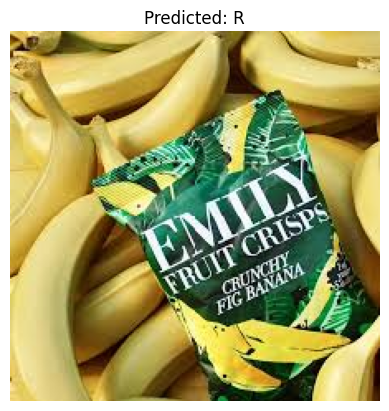

In [ ]:
class_labels = list(test_generator.class_indices.keys())

for i in range(10):
    img, label = test_generator[i]
    prediction = model.predict(img)

    plt.imshow(img[0])
    plt.title("Predicted: " + class_labels[int(np.round(prediction[0]))])
    plt.axis("off")
    plt.show()

**Save Model (.h5 file)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/recyclable_organic_cnn_model.h5")

Mounted at /content/drive
